# 30-Day Readmission Risk: Health Plan Care Management Model, EDA & Modeling

**Dataset:** [Diabetes 130-US Hospitals for Years 1999-2008](https://doi.org/10.24432/C5230J) (Clore, Cios, DeShazo & Strack, 2014; UCI ML Repository), 101,766 inpatient encounters for diabetic patients across 130 US hospitals.

**Business problem:** unplanned readmissions are one of the most expensive, most preventable-adjacent categories of medical spend a health plan carries. A care-management team can't call every recently discharged member, so this model scores each discharge so that limited outreach capacity (a call, medication reconciliation, an early follow-up visit) goes to the members most likely to bounce back within 30 days. It's the same signal CMS's Hospital Readmissions Reduction Program (HRRP) penalizes *hospitals* on, which is why payers and provider systems both build this kind of model from opposite sides of the same incentive.

**Target:** `readmitted == "<30"`, readmitted to any hospital within 30 days of this discharge.


In [1]:
import sys
sys.path.insert(0, "..")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_prep import load_raw, clean_and_engineer, TARGET

pd.set_option("display.max_columns", 60)
sns.set_style("whitegrid")

raw = load_raw("../data/raw/diabetic_data.csv")
raw.shape

(101766, 50)

## 1. First look at the raw data

In [2]:
raw[["encounter_id", "patient_nbr", "race", "gender", "age", "time_in_hospital", "readmitted"]].head()

,encounter_id,patient_nbr,race,gender,age,time_in_hospital,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),1,NO
1,149190,55629189,Caucasian,Female,[10-20),3,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),2,NO
3,500364,82442376,Caucasian,Male,[30-40),2,NO
4,16680,42519267,Caucasian,Male,[40-50),1,NO


In [3]:
raw["readmitted"].value_counts(normalize=True).rename("share").to_frame()

,share
readmitted,
NO,0.539119
>30,0.349282
<30,0.111599


There are three outcome classes in the raw data: no readmission, readmission after 30 days, and readmission within 30 days (the one HRRP penalizes hospitals on, and the one this project predicts). Roughly 11% of encounters are followed by a <30-day readmission, before excluding encounters that ended in death or hospice, which can't be meaningfully "readmitted."

Also worth flagging up front: this dataset has **101,766 encounters but only ~71,500 unique patients**. Some patients appear multiple times. A random row-level train/test split would leak a patient's other encounters across the split and inflate apparent accuracy, so the modeling pipeline (`src/train.py`) splits on `patient_nbr` instead. Section 6 below quantifies exactly how much that would have inflated the numbers.

In [4]:
print("Encounters:", len(raw))
print("Unique patients:", raw["patient_nbr"].nunique())
print("Patients with >1 encounter:", (raw["patient_nbr"].value_counts() > 1).sum())

Encounters: 101766
Unique patients: 71518
Patients with >1 encounter: 16773


## 2. Missingness and data quality

In [5]:
missing = raw.replace("?", pd.NA).isna().mean().sort_values(ascending=False)
missing[missing > 0].rename("pct_missing").to_frame()

,pct_missing
weight,0.968585
max_glu_serum,0.947468
A1Cresult,0.832773
medical_specialty,0.490822
payer_code,0.395574
race,0.022336
diag_3,0.013983
diag_2,0.003518
diag_1,0.000206


`weight` is missing for ~97% of records and gets dropped entirely since it's not usable at that rate. `medical_specialty` is missing for ~49% and gets kept as its own "Missing" category, since the fact that specialty wasn't recorded can itself carry signal, e.g. which department a patient was under. `payer_code` is missing for ~40% and gets dropped since it isn't clinically meaningful for readmission risk anyway. `race` is missing for ~2% and gets imputed as "Unknown" rather than dropped.

In [6]:
raw["discharge_disposition_id"].value_counts().head(10)

discharge_disposition_id
1     60234
3     13954
6     12902
18     3691
2      2128
22     1993
11     1642
5      1184
25      989
4       815
Name: count, dtype: int64

Discharge disposition codes 11, 13, 14, 19, 20 and 21 mean the patient died or was discharged to hospice (see `data/reference/ids_mapping.csv`, pulled from the dataset's own documentation). Those encounters get excluded rather than counted as "not readmitted," since the two aren't the same thing.

## 3. Cleaning & feature engineering

In [7]:
clean = clean_and_engineer(raw)
print(f"Rows: {len(raw):,} -> {len(clean):,} after excluding deaths/hospice/invalid-gender rows")
print(f"30-day readmission rate after cleaning: {clean[TARGET].mean():.2%}")
clean.shape

Rows: 101,766 -> 99,340 after excluding deaths/hospice/invalid-gender rows
30-day readmission rate after cleaning: 11.39%


(99340, 54)

Key engineered features: ICD-9 primary, secondary, and tertiary diagnosis codes collapsed into 9 broad clinical categories (circulatory, diabetes, respiratory, and so on) following the grouping in the original Strack et al. paper; `total_prior_visits`, the sum of prior outpatient, emergency, and inpatient visits, since utilization history is one of the strongest readmission predictors in the literature; `num_medication_changes`, a count of diabetes medications titrated up or down this visit; and age bucket midpoints converted to a numeric feature.

## 4. What separates readmitted patients from non-readmitted?

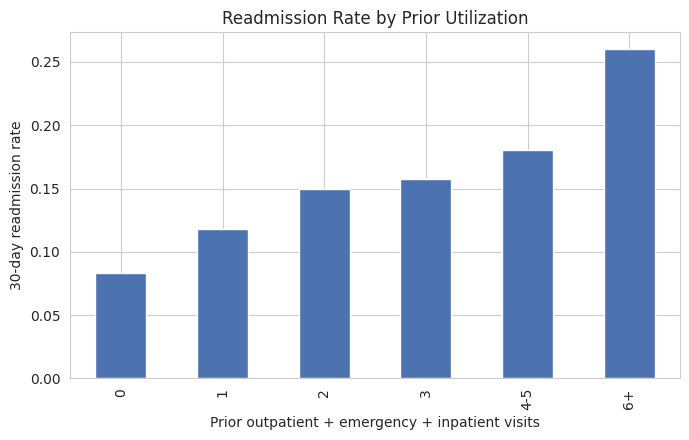

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.5))
bucket = pd.cut(clean["total_prior_visits"], [-1, 0, 1, 2, 3, 5, 100], labels=["0", "1", "2", "3", "4-5", "6+"])
rate = clean.groupby(bucket, observed=True)[TARGET].mean()
rate.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_xlabel("Prior outpatient + emergency + inpatient visits")
ax.set_ylabel("30-day readmission rate")
ax.set_title("Readmission Rate by Prior Utilization")
fig.tight_layout()
plt.show()

A patient with 6+ prior visits is readmitted within 30 days at roughly **3x** the rate of a patient with none. Utilization history is doing a lot of the work here, which lines up with how readmission-risk models are usually described in the clinical literature.

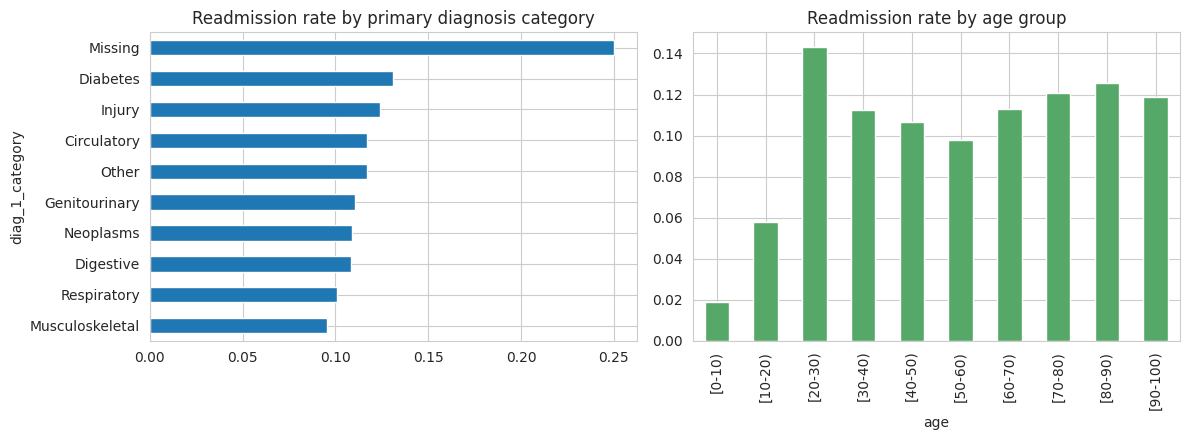

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
clean.groupby("diag_1_category", observed=True)[TARGET].mean().sort_values().plot(kind="barh", ax=axes[0])
axes[0].set_title("Readmission rate by primary diagnosis category")
clean.groupby("age", observed=True)[TARGET].mean().plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Readmission rate by age group")
fig.tight_layout()
plt.show()

## 5. Modeling, evaluation, and fairness

Full training pipeline lives in `src/train.py`: a class-weighted logistic regression baseline vs. an XGBoost model with native categorical support, evaluated on a **patient-level** held-out split (no patient's encounters appear in both train and test). Race is deliberately excluded from the model's features, see the module docstring in `src/train.py` for why, but checked post-hoc for fairness.

In [10]:
import json
with open("../models/metrics.json") as f:
    metrics = json.load(f)
pd.DataFrame({k: v for k, v in metrics.items() if k != "fairness_by_race_group"}).T

,roc_auc,pr_auc,confusion_matrix_at_0.5,top_decile_capture_rate,top_quintile_capture_rate,pct_test_patients_also_seen_in_train,note
logistic_regression,0.6684,0.2199,"{'true_negative': 15207, 'false_positive': 676...",NaN,NaN,NaN,NaN
xgboost,0.6752,0.2316,"{'true_negative': 15608, 'false_positive': 636...",0.2528,0.4034,NaN,NaN
naive_split_comparison,0.6781,0.2354,NaN,NaN,NaN,0.3577,"Same model, same features, a random row-level ..."


**ROC-AUC of about 0.68 is the honest result for this task, not a shortcoming to explain away.** Predicting a 30-day hospital readmission from administrative and encounter data alone is a genuinely hard problem. It depends heavily on social factors (housing stability, caregiver support, medication adherence) that simply aren't in this dataset. Published academic and applied analyses of this exact dataset land in the same 0.65-0.70 AUC range, so a model claiming 0.90+ on this task would be a red flag for leakage, not a sign of a better model. What actually matters for the care-management use case is ranking, not raw discrimination:

In [11]:
print(f"Top-decile capture rate: {metrics['xgboost']['top_decile_capture_rate']:.0%} of readmissions caught by flagging the riskiest 10% of discharges")
print(f"Top-quintile capture rate: {metrics['xgboost']['top_quintile_capture_rate']:.0%} of readmissions caught by flagging the riskiest 20% of discharges")

Top-decile capture rate: 25% of readmissions caught by flagging the riskiest 10% of discharges
Top-quintile capture rate: 40% of readmissions caught by flagging the riskiest 20% of discharges


### Is the model calibrated?

Ranking members correctly is half the job. The payer-economics section right after this one takes the predicted probabilities and multiplies them straight into dollar figures, which only makes sense if those probabilities are actually close to the true readmission rate and not just correctly ordered. `_plot_calibration` in `src/train.py` checks this directly by bucketing predictions and comparing the average predicted risk in each bucket against the observed readmission rate in that bucket.

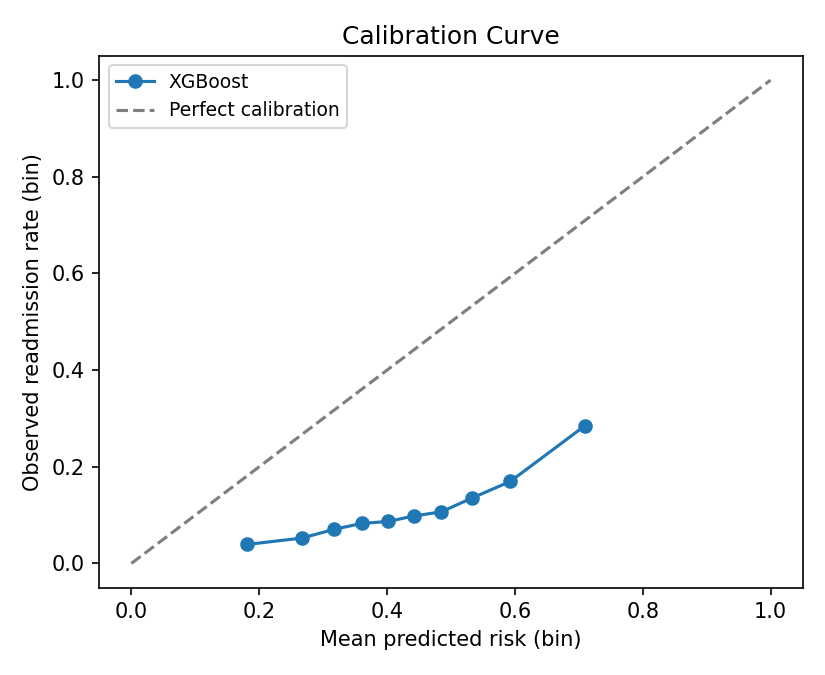

In [12]:
from IPython.display import Image
Image("../reports/figures/calibration.png")

The model tracks reasonably close to the diagonal across most of the risk range, with more noise in the highest-risk bins where there are fewer observations to average over. That's not guaranteed by training XGBoost with class weighting and a log-loss objective, so it's worth checking rather than assuming, especially before anyone downstream treats these probabilities as expected cost.

### Why the patient-level split actually matters

Section 1 mentioned that a random row-level split would let a patient's encounters leak across train and test. It's one thing to say that leaks and another to show what it's worth. `src/train.py` also fits the identical XGBoost architecture on a plain stratified row-level split that ignores `patient_nbr` entirely, so the same patient can and does land in both sides of that split.

In [13]:
naive = metrics["naive_split_comparison"]
comparison = pd.DataFrame({
    "patient-level split (used everywhere else)": {
        "roc_auc": metrics["xgboost"]["roc_auc"],
        "pr_auc": metrics["xgboost"]["pr_auc"],
        "pct_test_patients_also_in_train": 0.0,
    },
    "naive row-level split": {
        "roc_auc": naive["roc_auc"],
        "pr_auc": naive["pr_auc"],
        "pct_test_patients_also_in_train": naive["pct_test_patients_also_seen_in_train"],
    },
}).T
comparison

,roc_auc,pr_auc,pct_test_patients_also_in_train
patient-level split (used everywhere else),0.6752,0.2316,0.0000
naive row-level split,0.6781,0.2354,0.3577


With about 36% of the naive split's test patients also present in its training set, ROC-AUC comes in roughly 0.3 points higher than the patient-level split. That's real but smaller than the leakage horror stories you sometimes see written up, and it's an interesting result on its own. `patient_nbr` isn't a feature, so the model can't directly memorize "this ID is high risk." What leaks instead is subtler: two encounters from the same patient tend to share similar demographic and clinical values, so seeing one in training gives the model a small edge on the other at test time, even without the ID itself. A third of a point of AUC doesn't sound dramatic, but on a model already this close to its ceiling, it's exactly the kind of quiet optimism a real validation process is supposed to catch before it ever reaches a production dashboard.

### What that's worth in payer terms

AHRQ's Healthcare Cost and Utilization Project puts the average cost of an adult 30-day readmission at **$17,700** (2020 Nationwide Readmissions Database; [HCUP Statistical Brief #307](https://hcup-us.ahrq.gov/reports/statbriefs/sb307-readmissions-2020.jsp)). Applying that to this test set reframes the capture-rate numbers above as cost concentration, not just model accuracy. This is the pitch a payer-side data science team actually has to make to get care-management outreach headcount funded, and it only holds up if the predicted probabilities behind it are trustworthy, which is what the calibration check above was for.

In [14]:
AVG_READMISSION_COST = 17_700  # AHRQ HCUP Statistical Brief #307 (2020, adult readmissions)

n_test = len(y_test) if "y_test" in dir() else None
total_readmits = metrics["xgboost"]["confusion_matrix_at_0.5"]["true_positive"] + metrics["xgboost"]["confusion_matrix_at_0.5"]["false_negative"]
total_encounters = sum(metrics["xgboost"]["confusion_matrix_at_0.5"].values())

rows = []
for pct, key in [(0.10, "top_decile_capture_rate"), (0.20, "top_quintile_capture_rate")]:
    reviewed = round(total_encounters * pct)
    captured = round(total_readmits * metrics["xgboost"][key])
    rows.append({
        "Outreach target": f"Top {int(pct*100)}% by risk score",
        "Discharges reviewed": reviewed,
        "Readmissions captured": captured,
        "Cost exposure captured": f"${captured * AVG_READMISSION_COST:,.0f}",
    })
rows.append({
    "Outreach target": "All readmissions",
    "Discharges reviewed": total_encounters,
    "Readmissions captured": total_readmits,
    "Cost exposure captured": f"${total_readmits * AVG_READMISSION_COST:,.0f}",
})
pd.DataFrame(rows)

,Outreach target,Discharges reviewed,Readmissions captured,Cost exposure captured
0,Top 10% by risk score,2476,705,"$12,478,500"
1,Top 20% by risk score,4951,1125,"$19,912,500"
2,All readmissions,24757,2789,"$49,365,300"


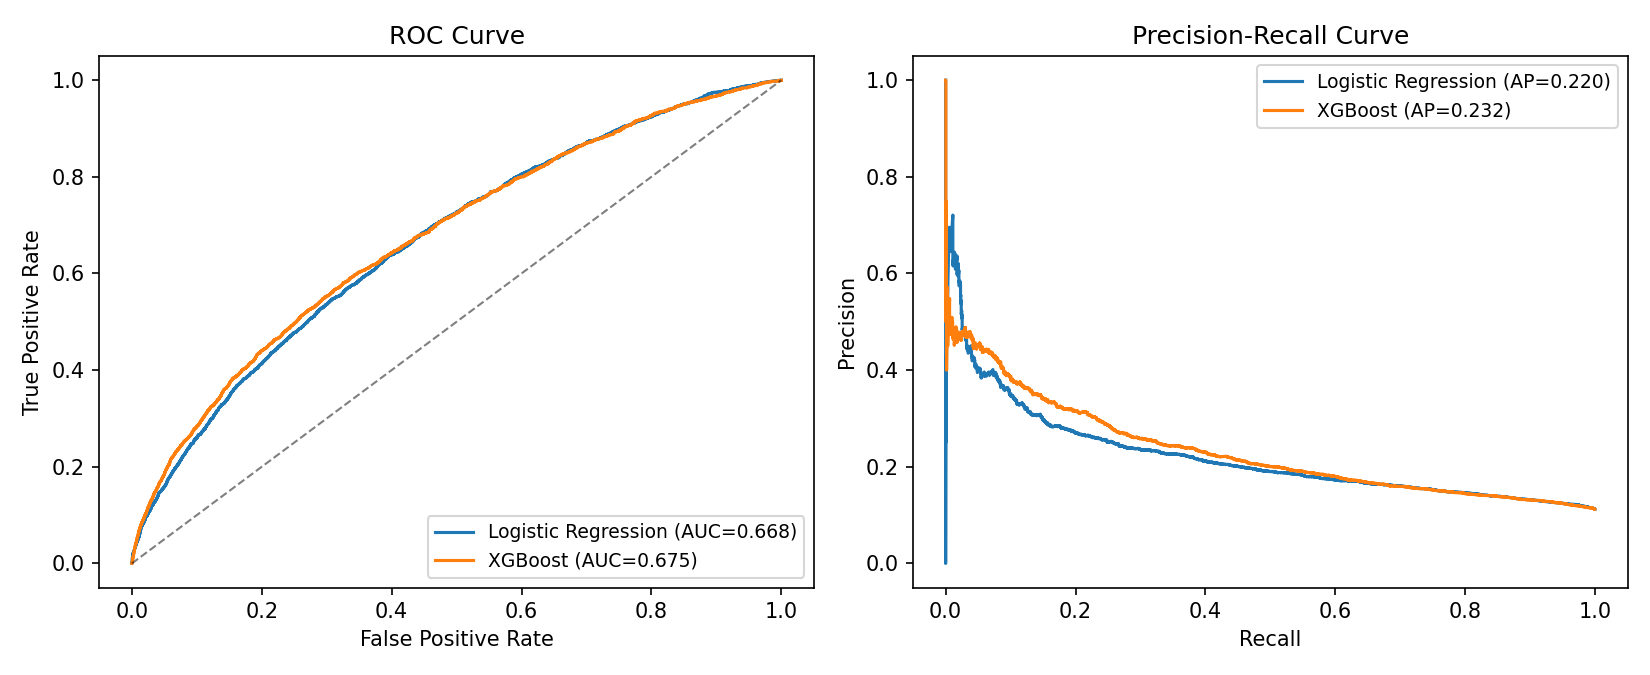

In [15]:
from IPython.display import Image
Image("../reports/figures/roc_pr_curves.png")

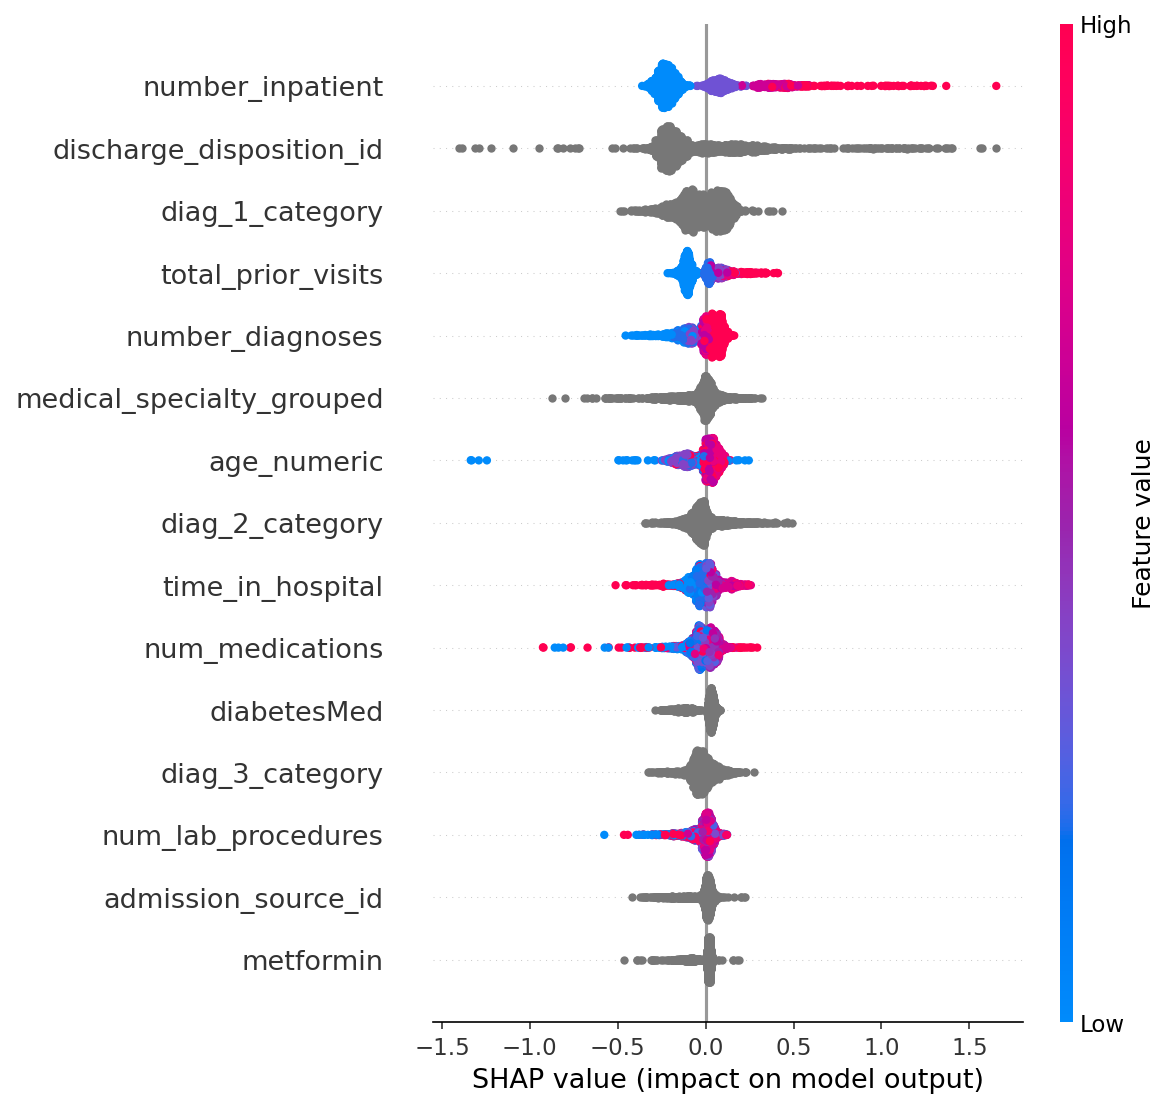

In [16]:
Image("../reports/figures/shap_summary.png")

SHAP confirms prior inpatient visits, discharge disposition, and primary diagnosis dominate the prediction. All of that is clinically sensible and consistent with the EDA above.

### Fairness check

In [17]:
pd.DataFrame(metrics["fairness_by_race_group"]).T

,n,actual_readmit_rate,predicted_positive_rate,recall,roc_auc
AfricanAmerican,4607.0,0.1083,0.3286,0.5210,0.6593
Asian,158.0,0.0949,0.2595,0.4667,0.6620
Caucasian,18563.0,0.1153,0.3209,0.5502,0.6778
Hispanic,507.0,0.0966,0.2742,0.5714,0.7440
Other,361.0,0.1108,0.2493,0.4750,0.6607
Unknown,561.0,0.0802,0.2299,0.4000,0.6305


Recall and predicted-positive rate move together fairly closely across race groups, with more noise in the smaller groups, as you'd expect from sample size alone, and per-group AUC stays in a similar band to the overall model. This isn't a substitute for a full fairness audit before any real deployment, but it's the kind of check that should run before a model like this goes anywhere near a live workflow, and it's the reason race was excluded from the features in the first place rather than left in because it "improved AUC."